In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [12]:
import pandas as pd


nav = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\02_nav_history.csv")

scheme = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\07_scheme_performance.csv")

benchmark = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\10_benchmark_indices.csv")

In [13]:
print(nav.head())
print(nav.columns)

print(benchmark.head())
print(benchmark.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='object')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


In [14]:
nav['date'] = pd.to_datetime(nav['date'])

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [15]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [16]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


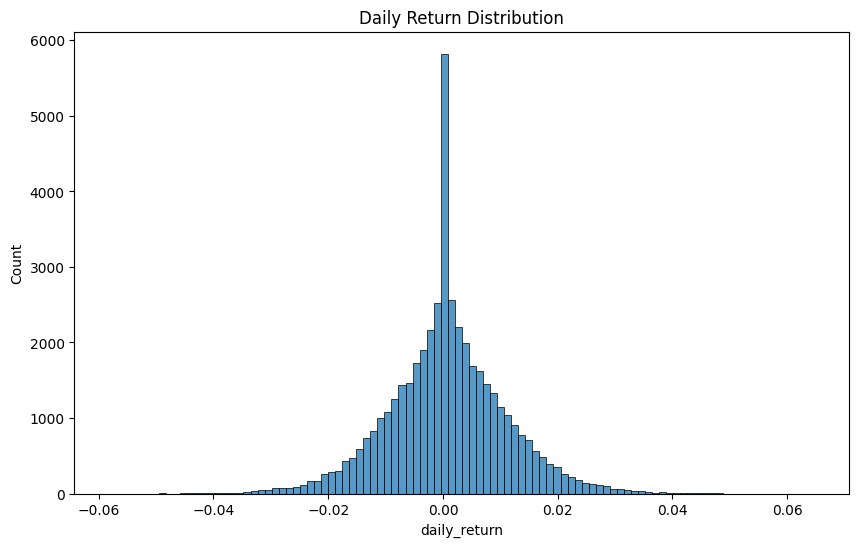

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [22]:
def cagr(
    start_nav,
    end_nav,
    years
):
    return (
        (end_nav/start_nav)
        **(1/years)
        -1
    )

In [23]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    df = nav[
        nav['amfi_code']==fund
    ].sort_values('date')

    start_nav = df['nav'].iloc[0]

    end_nav = df['nav'].iloc[-1]

    cagr_5yr = cagr(
        start_nav,
        end_nav,
        5
    )

    cagr_results.append(
        [fund,cagr_5yr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr_5yr'
    ]
)

cagr_df.head()

,amfi_code,cagr_5yr
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


In [25]:
sharpe_results = []
RF = 0.065

for fund in nav['amfi_code'].unique():

    returns = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    annual_return = (
        returns.mean()*252
    )

    annual_vol = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_vol

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()


,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [26]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    returns = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()*252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [27]:
print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [28]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [29]:
print(nifty100.shape)

(1150, 3)


In [30]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [31]:
alpha_beta_results = []

In [32]:
for fund in nav['amfi_code'].unique():

    fund_df = nav[
        nav['amfi_code'] == fund
    ][['date','daily_return']]

    merged = pd.merge(
        fund_df,
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        annual_alpha = alpha * 252

        alpha_beta_results.append(
            [fund, annual_alpha, beta]
        )

In [33]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
alpha_beta_df.to_csv(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\outputs\\alpha_beta.csv",
    index=False
)

In [36]:
import os

print(os.listdir("../outputs"))

['alpha_beta.csv']


In [37]:
mdd_results = []

for fund in nav['amfi_code'].unique():

    df = nav[
        nav['amfi_code'] == fund
    ].copy()

    df = df.sort_values('date')

    df['running_max'] = df['nav'].cummax()

    df['drawdown'] = (
        df['nav'] /
        df['running_max']
        - 1
    )

    max_dd = df['drawdown'].min()

    mdd_results.append(
        [fund, max_dd]
    )

In [38]:
mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [39]:
mdd_df.sort_values(
    'max_drawdown'
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [40]:
print(scheme.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [41]:
scheme['return_rank'] = (
    scheme['return_3yr_pct']
    .rank(ascending=False)
)

In [44]:
scheme['expense_rank'] = (
    scheme['expense_ratio_pct']
    .rank(ascending=True)
)

In [46]:
scorecard = (
    scheme[
        [
            'amfi_code',
            'scheme_name',
            'return_rank',
            'expense_rank'
        ]
    ]
    .merge(
        sharpe_df[
            [
                'amfi_code',
                'sharpe_rank'
            ]
        ],
        on='amfi_code'
    )
    .merge(
        alpha_beta_df[
            [
                'amfi_code',
                'alpha_rank'
            ]
        ],
        on='amfi_code'
    )
    .merge(
        mdd_df[
            [
                'amfi_code',
                'mdd_rank'
            ]
        ],
        on='amfi_code'
    )
)

In [48]:
scorecard['raw_score'] = (
    scorecard['return_rank'] * 0.30
    +
    scorecard['sharpe_rank'] * 0.25
    +
    scorecard['alpha_rank'] * 0.20
    +
    scorecard['expense_rank'] * 0.15
    +
    scorecard['mdd_rank'] * 0.10
)

In [45]:
mdd_df['mdd_rank'] = (
    mdd_df['max_drawdown']
    .rank(ascending=False)
)

In [49]:
scorecard['fund_score'] = (
    100
    *
    (
        scorecard['raw_score'].max()
        -
        scorecard['raw_score']
    )
    /
    (
        scorecard['raw_score'].max()
        -
        scorecard['raw_score'].min()
    )
)

In [43]:
alpha_beta_df['alpha_rank'] = (
    alpha_beta_df['alpha']
    .rank(ascending=False)
)

In [42]:
sharpe_df['sharpe_rank'] = (
    sharpe_df['sharpe_ratio']
    .rank(ascending=False)
)

In [7]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip.csv', 'hdfc_top100.csv', 'icici_bluechip.csv', 'kotak_bluechip.csv', 'nippon_large_cap.csv', 'sbi_bluechip.csv']


In [50]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,return_rank,expense_rank,sharpe_rank,alpha_rank,mdd_rank,raw_score,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,8.0,15.0,5.0,3.0,25.0,9.000,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,11.0,22.0,2.0,5.0,13.0,9.400,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.0,17.0,7.0,6.0,20.0,10.500,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.0,21.0,14.0,1.0,36.0,10.750,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,17.0,23.0,1.0,7.0,8.0,11.000,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,6.0,26.5,13.0,2.0,37.0,13.125,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,9.0,38.0,6.0,8.0,22.0,13.700,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,20.0,12.0,10.0,13.0,12.0,14.100,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,15.0,17.0,11.0,9.0,28.0,14.400,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,23.0,36.5,3.0,4.0,21.0,16.025,67.401392


In [51]:
scorecard.to_csv(
    "C:\\Users\\ABHILASH\\mutual_fund_project\\outputs\\fund_scorecard.csv",
    index=False
)

In [52]:
scorecard.head(5)

,amfi_code,scheme_name,return_rank,expense_rank,sharpe_rank,alpha_rank,mdd_rank,raw_score,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,8.0,15.0,5.0,3.0,25.0,9.00,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,11.0,22.0,2.0,5.0,13.0,9.40,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.0,17.0,7.0,6.0,20.0,10.50,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.0,21.0,14.0,1.0,36.0,10.75,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,17.0,23.0,1.0,7.0,8.0,11.00,90.719258


In [53]:
sbi = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\sbi_bluechip.csv")
hdfc = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\hdfc_top100.csv")
icici = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\icici_bluechip.csv")
kotak = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\kotak_bluechip.csv")
nippon = pd.read_csv("C:\\Users\\ABHILASH\\mutual_fund_project\\data\\raw\\nippon_large_cap.csv")

In [54]:
for df in [sbi, hdfc, icici, kotak, nippon]:
    df['date'] = pd.to_datetime(
        df['date'],
        dayfirst=True
    )

In [55]:
sbi['normalized'] = (
    sbi['nav']
    / sbi['nav'].iloc[-1]
) * 100

hdfc['normalized'] = (
    hdfc['nav']
    / hdfc['nav'].iloc[-1]
) * 100

icici['normalized'] = (
    icici['nav']
    / icici['nav'].iloc[-1]
) * 100

kotak['normalized'] = (
    kotak['nav']
    / kotak['nav'].iloc[-1]
) * 100

nippon['normalized'] = (
    nippon['nav']
    / nippon['nav'].iloc[-1]
) * 100

In [56]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty50['date'] = pd.to_datetime(
    nifty50['date']
)

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

In [ ]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty50['date'] = pd.to_datetime(
    nifty50['date']
)

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

In [57]:
nifty50['normalized'] = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
) * 100

nifty100['normalized'] = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

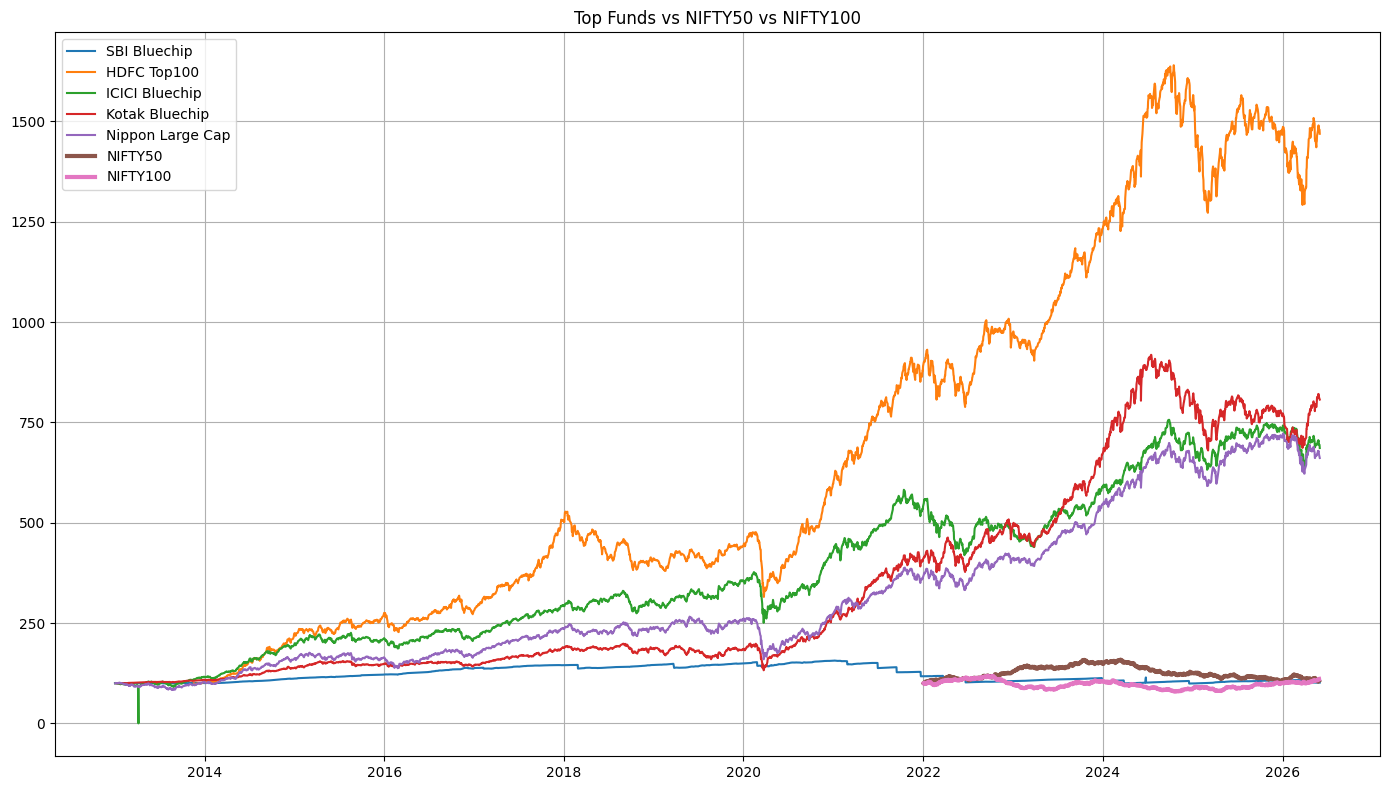

In [58]:
plt.figure(figsize=(14,8))

plt.plot(
    sbi['date'],
    sbi['normalized'],
    label='SBI Bluechip'
)

plt.plot(
    hdfc['date'],
    hdfc['normalized'],
    label='HDFC Top100'
)

plt.plot(
    icici['date'],
    icici['normalized'],
    label='ICICI Bluechip'
)

plt.plot(
    kotak['date'],
    kotak['normalized'],
    label='Kotak Bluechip'
)

plt.plot(
    nippon['date'],
    nippon['normalized'],
    label='Nippon Large Cap'
)

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    label='NIFTY50',
    linewidth=3
)

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    label='NIFTY100',
    linewidth=3
)

plt.title(
    "Top Funds vs NIFTY50 vs NIFTY100"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

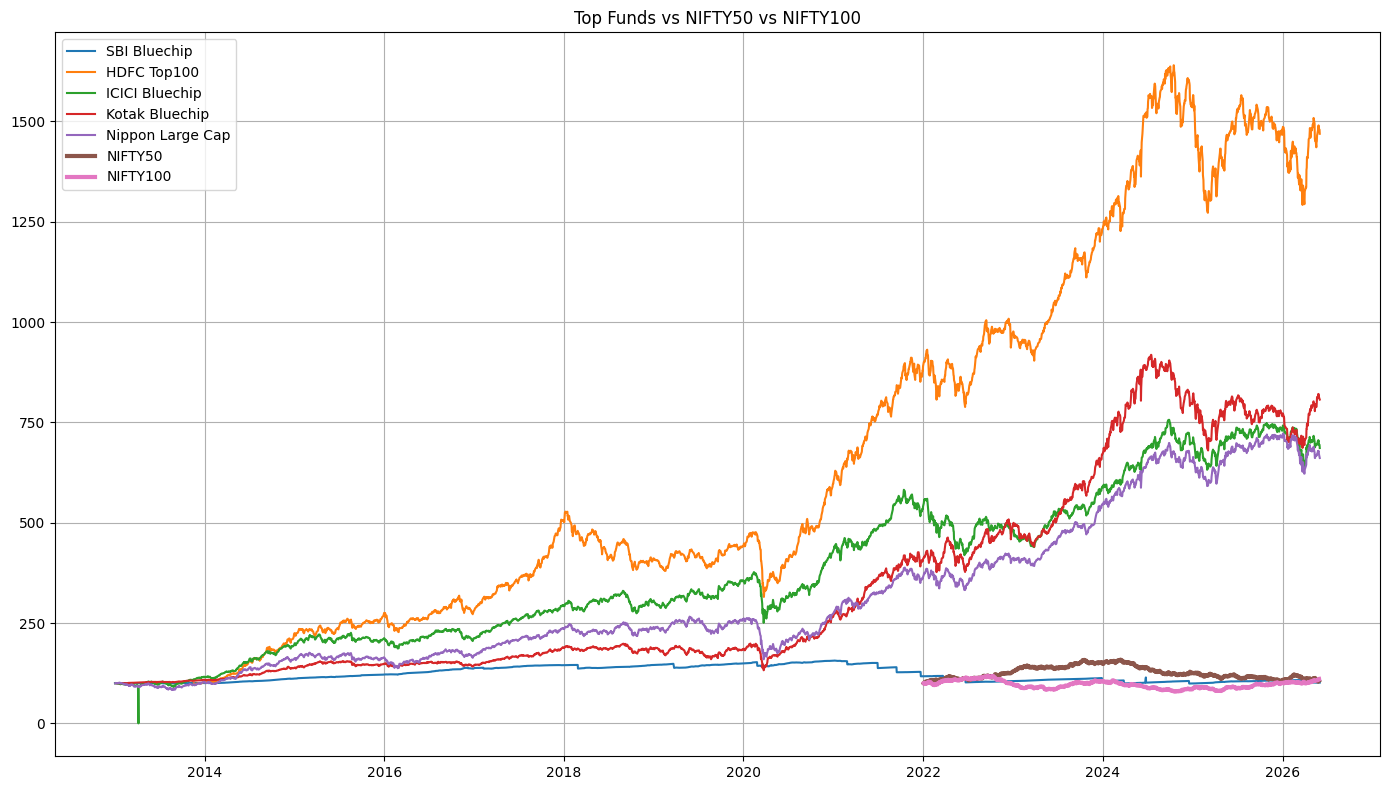

In [59]:
plt.figure(figsize=(14,8))

plt.plot(
    sbi['date'],
    sbi['normalized'],
    label='SBI Bluechip'
)

plt.plot(
    hdfc['date'],
    hdfc['normalized'],
    label='HDFC Top100'
)

plt.plot(
    icici['date'],
    icici['normalized'],
    label='ICICI Bluechip'
)

plt.plot(
    kotak['date'],
    kotak['normalized'],
    label='Kotak Bluechip'
)

plt.plot(
    nippon['date'],
    nippon['normalized'],
    label='Nippon Large Cap'
)

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    label='NIFTY50',
    linewidth=3
)

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    label='NIFTY100',
    linewidth=3
)

plt.title(
    "Top Funds vs NIFTY50 vs NIFTY100"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
sbi = sbi.sort_values('date')

sbi['return'] = sbi['nav'].pct_change()

merged = pd.merge(
    sbi[['date','return']],
    nifty100[['date','close_value']],
    on='date'
)

merged['benchmark_return'] = (
    merged['close_value']
    .pct_change()
)

tracking_error = (
    (merged['return']
     -
     merged['benchmark_return'])
    .std()
    *
    np.sqrt(252)
)

print(tracking_error)

0.1783797990315806


In [61]:
import os

print(os.listdir("../outputs"))

['alpha_beta.csv', 'benchmark_comparison.png', 'fund_scorecard.csv']
